In [72]:
import os
import copy
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
import matplotlib.gridspec as gridspec
import scipy 

import seaborn as sns
from IPython.display import Markdown as md
from dekef.base_density import *

from matplotlib import ticker, cm

from mpl_toolkits.axes_grid1.inset_locator import inset_axes

from matplotlib.patches import Ellipse

In [2]:
df = np.load('../data/geyser.npy').astype(np.float64)
waiting = df[:, 0].reshape(-1, 1)
waiting = waiting[waiting != 108.0]

In [3]:
info_coord = (0.03, 0.8)
info_coord1 = (0.03, 0.97)
info_coord2 = (0.03, 0.87)

In [4]:
label_fontsize = 25
info_fontsize = 28
tick_fontsize = 20
legend_fontsize = 30
linewidth = 4.0

In [91]:
contam_data_list =  np.arange(20, 182, 2) 
log_pen_list = np.arange(-12., 0.5, 0.5)
bw = 5.0
kernel_type = 'gaussian_poly2'

file_name = f'../data/data=waiting-bw={bw}-kernel={kernel_type}-empirical-inf-fun-summary-baseden=Gamma-36-2-gridpoints=1-202-1.xlsx'
summary_df_sm = pd.read_excel(file_name, f'SM-result')

# file_name = f'../data/data=waiting-bw={bw}-kernel={kernel_type}-contamweight=0.001-summary-baseden=Gamma-26-3-gridpoints=1-231-1.xlsx'
# summary_df_sm = pd.read_excel(file_name, f'Sheet1')

summary_df_sm = summary_df_sm[summary_df_sm.contam_data <= 180.0]

## Overall influence vs. log rho 

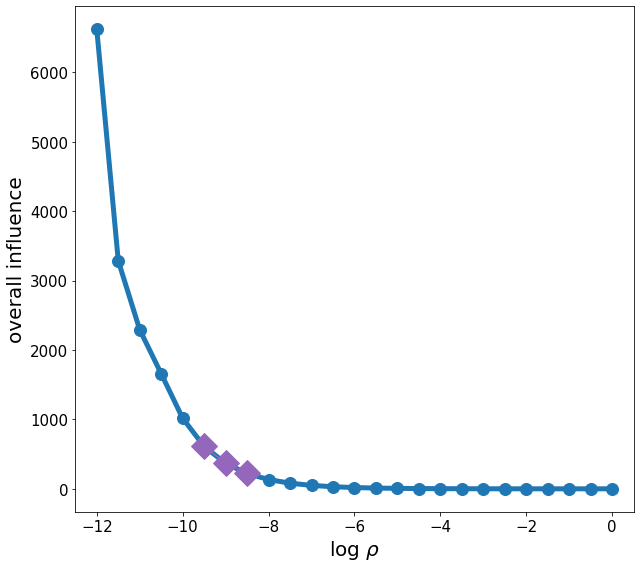

In [93]:
contam_data = 108.0

info_coord = (0.965, 0.965)
horizontalalignment, verticalalignment = 'right', 'top'

label_fontsize = 20
info_fontsize = 35
tick_fontsize = 15
legend_fontsize = 25
linewidth = 5.0
x_label = r'waiting'
y_label = r'log density'

nrows = 1
ncols = 1

fig = plt.figure(figsize=(9, 8))
gs = gridspec.GridSpec(nrows = nrows, ncols = ncols)

color = 'tab:blue'

# ----------------------------------------------------------------------------------------
# fix y = 120, vary penalty parameter
ax2 = fig.add_subplot(gs[0, 0])

subdf = summary_df_sm[summary_df_sm.contam_data == contam_data]

# subdf.loc[141, 'IF_supnorm_original'] = subdf.loc[141, 'IF_supnorm_original'] + 1000.

ax2.plot(subdf.log_lambda, subdf.IF_supnorm_original, color = 'tab:blue', marker = 'o', markersize = 12)
ax2.plot(subdf.log_lambda, subdf.IF_supnorm_original, linewidth = linewidth, color = color)

index = [5, 6, 7]
ax2.plot(subdf.log_lambda.iloc[index], subdf.IF_supnorm_original.iloc[index], color = 'tab:purple', marker = 'D', 
         markersize = 18)

ax2.set_xlim(-12.5, .5)
# ax2.set_ylim(logden_plot_ylim)
ax2.set_xlabel(r'$\log \ \rho$', fontsize = label_fontsize)
ax2.set_ylabel(r'overall influence', fontsize = label_fontsize)
ax2.tick_params(axis = 'both', labelsize = tick_fontsize)
# ax2.set_xscale('log')

# ax2.set_xticks(xticks)
# ax2.set_xticklabels(xticks, size = tick_fontsize)

# info = "[{letter}]".format(letter = chr(65 + i * 3 + 1))
# ax2.text(*info_coord, 
#          info,
#          fontsize = info_fontsize,
#          multialignment = 'left',
#          horizontalalignment = horizontalalignment, 
#          verticalalignment = verticalalignment, 
#          transform = ax2.transAxes,
#          bbox = {'facecolor': 'none',
#                  'boxstyle': 'Round, pad=0.2'})

plt.tight_layout()

# plt.savefig(f'../plots/waiting-SM-overall-empirical-influence-log-penalty-params-choose-best-baseden=Gamma-36-2-gridpoints=1-202-1.pdf', 
#             bbox_inches = 'tight')
plt.show()


## make plot of density estimates 

In [80]:
true_data = np.load('../data/geyser.npy').astype(np.float64)
df = copy.deepcopy(true_data[:, 0]).reshape(-1, 1)

# original data with 108.0 removed 
data_waiting = df[df != 108.0]

grid_points = np.arange(1., 202.)
bw = 5.
kernel_type = 'gaussian_poly2'
plot_domain = (1., 210.)
plot_pts_cnt = 3000


base_density = BasedenGamma(data_waiting, 36., 2.)

sm_save_folder = (f'../data/data=geyser-waiting-PenSM-FinKEF-bw={bw}-kernel={kernel_type}-' +
                  f'empirical-inf-fun-plotdomain={plot_domain}-plotcnts={plot_pts_cnt}-' + 
                  f'baseden=gamma-{base_density.a}-{base_density.scale}-grid_points=1-202-1')
new_data = np.load(sm_save_folder + '/new_data.npy')

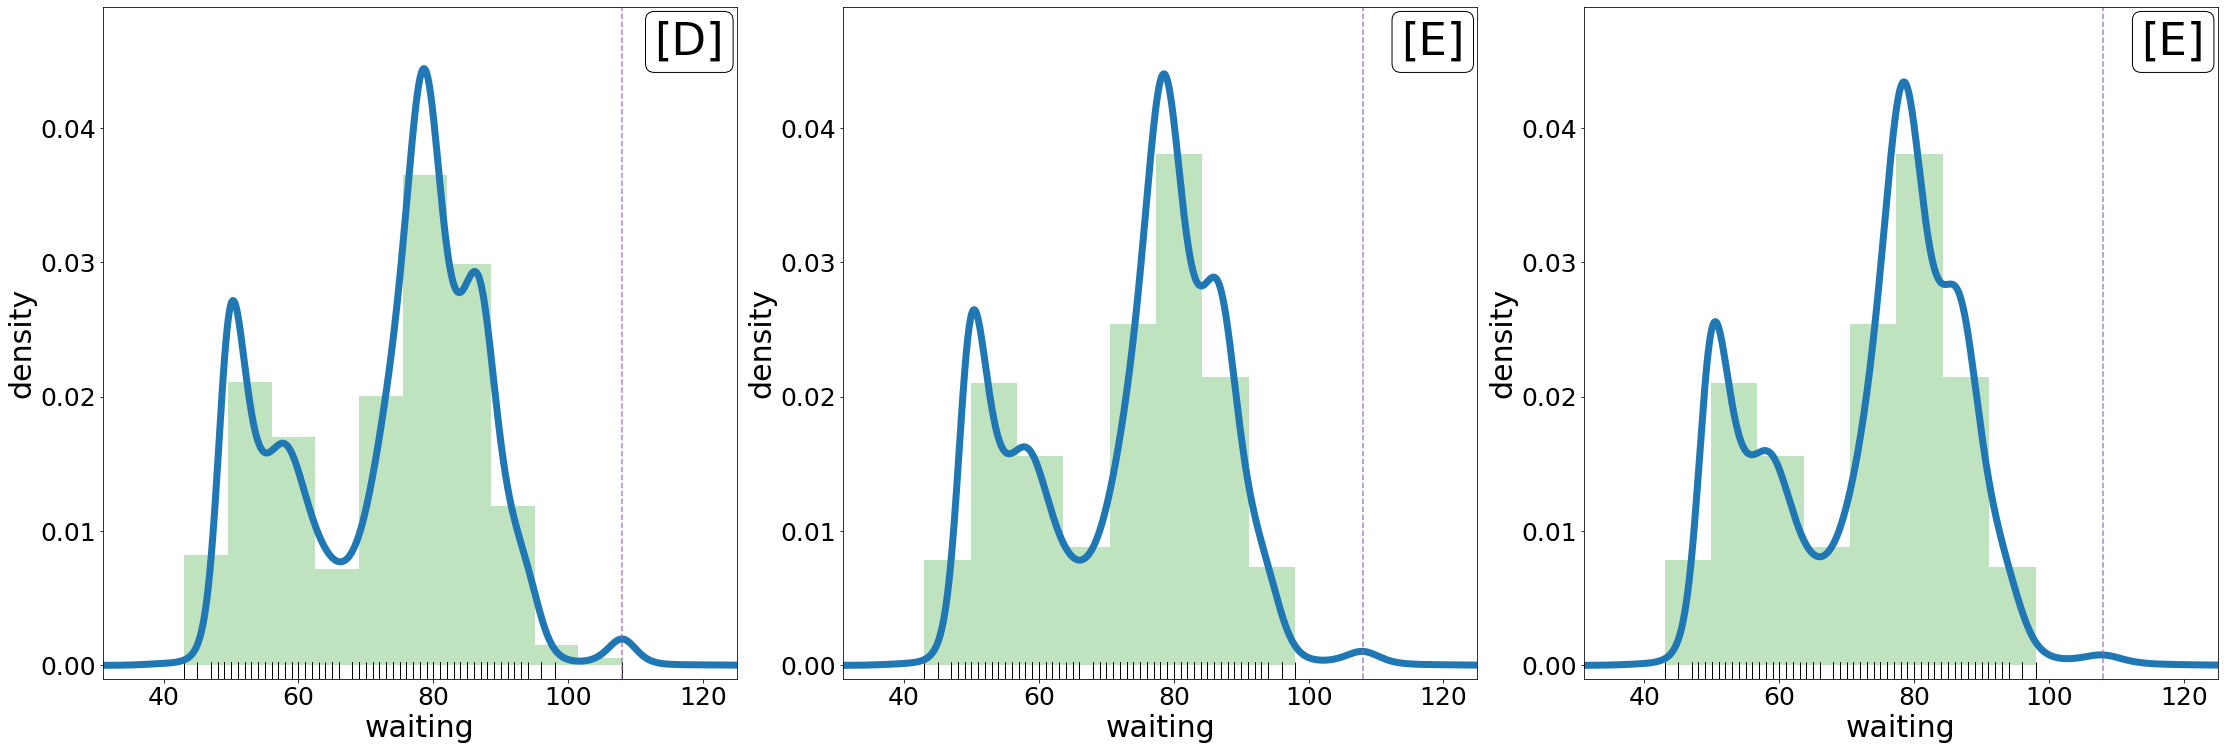

In [89]:
label_fontsize = 30
info_fontsize = 45
tick_fontsize = 25
legend_fontsize = 30
linewidth = 7.0
x_label1 = 'waiting'
x_label = r'evaluation point'
info_coord = (0.98, 0.98)
horizontalalignment, verticalalignment = 'right', 'top'

den_plot_xlim = (31., 125.)
logden_plot_ylim = (-43., 9.)
den_plot_ylim = (-0.001, 0.049)

contam_data = 108.
legend_loc = 'lower right'

xticks = [40, 60, 80, 100, 120]

nrows, ncols = 2, 3
fig = plt.figure(figsize=(31, 20))
gs = gridspec.GridSpec(nrows = nrows, ncols = ncols)

sm_log_pen_param = [-9.5, -9., -8.5]

# SM_logden0 = np.load(sm_save_folder + f'/logpenparam={sm_log_pen_param[0]}-uncontam-logden-newdata.npy')
# SM_logden1 = np.load(sm_save_folder + f'/logpenparam={sm_log_pen_param[1]}-uncontam-logden-newdata.npy')
# SM_logden2 = np.load(sm_save_folder + f'/logpenparam={sm_log_pen_param[2]}-uncontam-logden-newdata.npy')

SM_logden0 = np.load(sm_save_folder + f'/logpenparam={sm_log_pen_param[0]}-contam_data={contam_data}-contam-logden-newdata.npy')
SM_logden1 = np.load(sm_save_folder + f'/logpenparam={sm_log_pen_param[1]}-contam_data={contam_data}-contam-logden-newdata.npy')
SM_logden2 = np.load(sm_save_folder + f'/logpenparam={sm_log_pen_param[2]}-contam_data={contam_data}-contam-logden-newdata.npy')

# ========================================================================================
# ----------------------------------------------------------------------------------------
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(new_data.flatten(), np.exp(SM_logden0), linewidth = linewidth, 
         color = 'tab:blue', label = 'Score Matching')

ax1.set_xticks(xticks)
ax1.set_xticklabels(xticks, size = tick_fontsize)
ax1.hist(np.append(data_waiting, contam_data), bins='fd', density = True, alpha = 0.3, color = 'tab:green')
sns.rugplot(pd.Series(data_waiting.flatten()), ax = ax1, color = 'black')
sns.rugplot(pd.Series(np.array(contam_data).flatten()), ax = ax1, color = 'black')
ax1.axvline(contam_data, 0, 1, ls = '--', color = 'tab:purple', alpha = 0.8)
ax1.set_xlim(den_plot_xlim)
ax1.set_ylim(den_plot_ylim)
ax1.set_xlabel(x_label1, fontsize = label_fontsize)
ax1.set_ylabel(r'density', fontsize = label_fontsize)
ax1.tick_params(axis = 'both', labelsize = tick_fontsize)
# ax1.legend(loc = legend_loc, fontsize = label_fontsize)
# ax1.add_patch(ax1.add_artist(Ellipse((contam_data, 0.), 5., 0.0015, 
#                                      color = 'indigo', fill = False, linewidth = 4.0)))

info = "[{letter}]".format(letter = chr(68))
ax1.text(*info_coord,
         info,
         fontsize = info_fontsize,
         multialignment = 'left',
         horizontalalignment = horizontalalignment, 
         verticalalignment = verticalalignment, 
         transform = ax1.transAxes,
         bbox = {'facecolor': 'none',
                 'boxstyle': 'Round, pad=0.2'})

# ----------------------------------------------------------------------------------------
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(new_data.flatten(), np.exp(SM_logden1), 
         linewidth = linewidth, color = 'tab:blue', label = 'Score Matching')

ax2.set_xticks(xticks)
ax2.set_xticklabels(xticks, size = tick_fontsize)
ax2.hist(data_waiting, bins='fd', density = True, alpha = 0.3, color = 'tab:green')
sns.rugplot(pd.Series(data_waiting.flatten()), ax = ax2, color = 'black')
# sns.rugplot(pd.Series(np.array(contam_data).flatten()), ax = ax2, color = 'black')
ax2.axvline(contam_data, 0, 1, ls = '--', color = 'tab:purple', alpha = 0.8)
ax2.set_xlim(den_plot_xlim)
ax2.set_ylim(den_plot_ylim)
ax2.set_xlabel(x_label1, fontsize = label_fontsize)
ax2.set_ylabel(r'density', fontsize = label_fontsize)
ax2.tick_params(axis = 'both', labelsize = tick_fontsize)
# ax2.legend(loc = legend_loc, fontsize = label_fontsize)

info = "[{letter}]".format(letter = chr(69))
ax2.text(*info_coord,
         info,
         fontsize = info_fontsize,
         multialignment = 'left',
         horizontalalignment = horizontalalignment, 
         verticalalignment = verticalalignment, 
         transform = ax2.transAxes,
         bbox = {'facecolor': 'none',
                 'boxstyle': 'Round, pad=0.2'})

# ----------------------------------------------------------------------------------------
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(new_data.flatten(), np.exp(SM_logden2), 
         linewidth = linewidth, color = 'tab:blue', label = 'Score Matching')

ax3.set_xticks(xticks)
ax3.set_xticklabels(xticks, size = tick_fontsize)
ax3.hist(data_waiting, bins='fd', density = True, alpha = 0.3, color = 'tab:green')
sns.rugplot(pd.Series(data_waiting.flatten()), ax = ax3, color = 'black')
# sns.rugplot(pd.Series(np.array(contam_data).flatten()), ax = ax3, color = 'black')
ax3.axvline(contam_data, 0, 1, ls = '--', color = 'tab:purple', alpha = 0.8)
ax3.set_xlim(den_plot_xlim)
ax3.set_ylim(den_plot_ylim)
ax3.set_xlabel(x_label1, fontsize = label_fontsize)
ax3.set_ylabel(r'density', fontsize = label_fontsize)
ax3.tick_params(axis = 'both', labelsize = tick_fontsize)
# ax3.legend(loc = legend_loc, fontsize = label_fontsize)

info = "[{letter}]".format(letter = chr(69))
ax3.text(*info_coord,
         info,
         fontsize = info_fontsize,
         multialignment = 'left',
         horizontalalignment = horizontalalignment, 
         verticalalignment = verticalalignment, 
         transform = ax3.transAxes,
         bbox = {'facecolor': 'none',
                 'boxstyle': 'Round, pad=0.2'})

plt.tight_layout()

# plt.savefig(f'../plots/appro-density-estimates-gamma-{base_density.a}-{base_density.scale}.pdf', 
#             bbox_inches = 'tight')
